# MVP — Machine Learning & Analytics

**Nome:** João Lucas Mota Nogueira da Costa

**Matrícula:** 4052025002472

**Dataset:** [Steam Games Dataset](https://www.kaggle.com/datasets/fronkongames/steam-games-dataset?resource=download)

**Tipo de problema:** _Classificação / Regressão / Clusterização / Séries Temporais_  

## Checklist do MVP

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ✅ |
| Dataset descrito, com fonte, atributos e restrições | ✅ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ✅ |
| Análise exploratória objetiva, conectada à modelagem | ✅ |
| Divisão adequada em treino/teste e, se aplicável, validação | ✅ |
| Prevenção de vazamento de dados | ✅ |
| Tratamentos de dados justificados | ✅ |
| Pipeline ou sequência reprodutível de pré-processamento | ✅ |
| Modelo baseline definido | ✅ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ✅ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ✅ |
| Avaliação com métricas coerentes com o problema | ✅ |
| Discussão de overfitting/underfitting, limitações e melhorias | ✅ |
| Código limpo, organizado e executável do início ao fim | ✅ |
| Conclusão conectada ao objetivo inicial | ✅ |

# 1. Definição do problema

## 1.1 Descrição do problema

A indústria de jogos eletrônicos é marcada por alta competitividade e incerteza. Na plataforma Steam, uma das principais métricas de sucesso de um jogo é a taxa de aprovação da comunidade, calculada a partir da razão entre avaliações positivas e o total de avaliações. Essa métrica reflete a satisfação dos jogadores e influencia diretamente a visibilidade do jogo na plataforma, as recomendações algorítmicas e, consequentemente, as vendas.

Quem seria o usuário ou interessado nessa solução?

- Desenvolvedores de jogos (indie e AAA): para orientar decisões de desenvolvimento, localização e marketing antes do lançamento.

- Publishers e investidores: para avaliar o potencial de retorno de um jogo e alocar recursos de forma mais eficiente.

- Equipes de produto da Steam (em uma aplicação hipotética): para identificar jogos com potencial de destaque na plataforma.

Por que esse problema é relevante?

Prever a recepção da comunidade antes do lançamento reduz o risco financeiro em um mercado onde a maioria dos jogos não atinge visibilidade significativa. Além disso, entender quais atributos influenciam a aprovação dos jogadores fornece insights acionáveis para melhorar a qualidade do jogo, ajustar a estratégia de precificação e aumentar as chances de sucesso comercial.

## 1.2 Objetivo do MVP

Construir e avaliar modelos de regressão para estimar a taxa de aprovação de jogos na Steam com base em atributos disponíveis em diferentes momentos do ciclo de vida do jogo (pré-lançamento e pós-lançamento). A comparação entre modelos permite identificar quais características são mais preditivas e em qual estágio a previsão se torna mais confiável.


## 1.3 Tipo de problema

Tipo escolhido: Regressão

Justificativa: O target definido para o problema é a Approval_Rating, uma variável numérica contínua no intervalo [0,1], calculada a partir da razão entre avaliações positivas e o total de avaliações de um jogo na Steam. O objetivo é estimar esse valor com base em atributos do jogo, o que caracteriza um problema de regressão. Modelos de classificação não são adequados, pois não se busca atribuir um rótulo categórico (ex: "aprovado" ou "reprovado"), mas sim quantificar a taxa de aprovação esperada.

## 1.4 Premissas, hipóteses e critérios de sucesso

###Hipóteses iniciais:
1 - Atributos disponíveis antes do lançamento (preço, gêneros, plataformas, data de lançamento, número de conquistas) têm poder preditivo suficiente para estimar a taxa de aprovação de um jogo na Steam, ainda que com erro maior do que modelos que utilizam dados pós-lançamento.

2 - Variáveis relacionadas ao engajamento dos jogadores (tempo médio de jogo, proporção de engajamento recente) melhoram a capacidade preditiva do modelo em relação ao cenário exclusivamente pré-lançamento.

3 - A inclusão de métricas de popularidade (Peak CCU) e crítica (Metacritic score) produz o melhor desempenho preditivo, servindo como benchmark para os demais cenários.

###Critérios de sucesso:
- Métrica principal: RMSE (Root Mean Squared Error). A escolha se justifica por penalizar erros grandes, o que é relevante para o contexto de negócio, onde subestimar ou superestimar a taxa de aprovação pode levar a decisões equivocadas de investimento ou marketing.

- Resultado mínimo esperado: O modelo final deve superar o baseline (DummyRegressor que prevê a mediana) em pelo menos 15% no RMSE, demonstrando que as features selecionadas têm poder preditivo real.

### Restrição prática:
O treinamento do modelo deve ser concluído em menos de 10 minutos em ambiente Google Colab (CPU), garantindo viabilidade computacional para o escopo do MVP.


# 2. Ambiente, bibliotecas e reprodutibilidade

In [86]:
import os
import sys
import time
import random
import warnings
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown

from pathlib import Path
from datetime import datetime
from collections import Counter

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint
from sklearn.compose import make_column_selector

warnings.filterwarnings("ignore")

##2.1 Variáveis Globais

In [87]:
# === Variáveis Globais ===

# Target
TARGET = "Approval Rating"

# Tipo de problema
PROBLEM_TYPE = "regressao"

# Semente para reprodutibilidade
SEED = 19

# Limiar de avaliações para filtrar jogos
MIN_REVIEWS = 30

# Data de coleta para cálculo de Days_Since_Release
COLLECTION_DATE = pd.Timestamp('2026-07-02')

# Lista de colunas a serem descartadas permanentemente
DROP_COLUMNS = [
    "Estimated owners", "About the game", "Reviews",
    "Header image", "Website", "Support url", "Support email",
    "Metacritic url", "Score rank", "Notes", "Screenshots", "Movies",
    "Discount", "User score", "Recommendations",
    "Developers", "Publishers", "Genres"
]

# Colunas de identificação
ID_COLUMNS = ["AppID", "Name"]

# Coluna de data
DATE_COLUMN = "Release date"

# Top N tags a serem usadas como features binárias
TOP_TAGS_N = 16

print("Variáveis globais definidas:")
print(f"  TARGET: {TARGET}")
print(f"  PROBLEM_TYPE: {PROBLEM_TYPE}")
print(f"  SEED: {SEED}")
print(f"  MIN_REVIEWS: {MIN_REVIEWS}")
print(f"  COLLECTION_DATE: {COLLECTION_DATE}")
print(f"  TOP_TAGS_N: {TOP_TAGS_N}")
print(f"  DROP_COLUMNS: {len(DROP_COLUMNS)} colunas")

Variáveis globais definidas:
  TARGET: Approval Rating
  PROBLEM_TYPE: regressao
  SEED: 19
  MIN_REVIEWS: 30
  COLLECTION_DATE: 2026-07-02 00:00:00
  TOP_TAGS_N: 16
  DROP_COLUMNS: 18 colunas


In [88]:
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


#SEED = datetime.now().microsecond
#np.random.seed(SEED)
#random.seed(SEED)

#print("Python:", sys.version.split()[0])
#print("Seed:", SEED)

Python: 3.12.13
Seed: 19


## 2.2 Dependências adicionais

---

Nenhuma biblioteca extra foi necessária.

## 2.3 Funções auxiliares

In [89]:
def evaluate_regression(y_true, y_pred):
    """Calcula métricas básicas para regressão."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }

def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T

# 3. Seleção e carga dos dados

---

## 3.1 Fonte dos dados

###Fonte: [Steam Games Dataset](https://www.kaggle.com/datasets/fronkongames/steam-games-dataset?resource=download)

---

###Por que esse dataset foi escolhido:
A base reúne informações estruturadas de mais de 125 mil jogos disponíveis na plataforma Steam, incluindo atributos como preço, gêneros, suporte a plataformas, data de lançamento, avaliações da comunidade e métricas de engajamento. A diversidade e o volume de dados permitem explorar diferentes cenários de modelagem (pré-lançamento e pós-lançamento) com um mesmo conjunto de dados, o que está alinhado aos objetivos do projeto.

###Restrições ou condições consideradas:
Foram considerados apenas jogos com informações disponíveis para as variáveis de interesse (ex: Positive, Negative, Price, Genres, Release date). Além disso, jogos com menos de 30 avaliações totais (Positive + Negative) foram excluídos da modelagem, pois a estimativa da taxa de aprovação para esses casos apresenta baixa confiabilidade estatística.

###Questões éticas e de licenciamento:
O dataset é publicamente disponível no Kaggle e não contém informações pessoais identificáveis. Os dados são agregados por jogo e não por usuário, o que elimina riscos de privacidade. A licença do dataset permite uso acadêmico e educacional, conforme as diretrizes da plataforma Kaggle.


## 3.2 Carga dos dados

---

In [90]:
arquivo = Path('games_raw.csv')

if arquivo.is_file():
  print("Base de dados original encontrada!")
else:
  url = 'https://drive.google.com/file/d/1BlAnnHnwKVeUWvNLu7zqbl9wEYNyuLsp/view?usp=sharing'
  file_name = 'games_raw.csv'
  gdown.download(url, file_name, quiet=False, fuzzy=True)

arquivo_polido = Path('games.csv')
if not arquivo_polido.is_file():
  with open("games_raw.csv", "r", encoding="utf-8") as f:
    linhas = f.readlines()
  linhas[0] = linhas[0].replace("DiscountDLC count", "Discount,DLC count")
  with open("games.csv", "w", encoding="utf-8") as f:
    f.writelines(linhas)

df_raw = pd.read_csv('games.csv', index_col=False, sep=',')

print(f"Dataset carregado com {df_raw.shape[0]} linhas e {df_raw.shape[1]} colunas")
df_raw.head()

Base de dados original encontrada!
Dataset carregado com 125855 linhas e 40 colunas


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


## 3.3 Visão geral do dataset

---


In [91]:
print("Formato do dataset:", df_raw.shape)
print("\nTipos de dados:")
display(df_raw.dtypes.to_frame("tipo"))

Formato do dataset: (125855, 40)

Tipos de dados:


,tipo
AppID,int64
Name,object
Release date,object
Estimated owners,object
Peak CCU,int64
Required age,int64
Price,float64
Discount,int64
DLC count,int64
About the game,object


In [92]:
print("\nValores ausentes por coluna:")
display(df_raw.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
AppID,0
Name,1
Release date,0
Estimated owners,0
Peak CCU,0
Required age,0
Price,0
Discount,0
DLC count,0
About the game,8462


In [93]:
print("\nDuplicatas:", df_raw.duplicated().sum())


Duplicatas: 0


In [94]:
display(df_raw.sample(5, random_state=SEED))

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
95095,3603070,Hope Deferred,"Apr 8, 2025",0 - 20000,0,0,11.99,0,0,Hope Deferred is a first-person psychological ...,...,0,0,0,Tell All,Tell All,"Single-player,Full controller support,Camera C...",RPG,"RPG,Psychological Horror,First-Person,Nonlinea...",https://shared.akamai.steamstatic.com/store_it...,NaN
18301,3265060,Touhou Dystopian,"Oct 17, 2025",0 - 20000,0,0,7.99,20,0,This is a third-person action roguelite game. ...,...,10,682,10,Kay Lnk,Kay Lnk,"Single-player,Steam Achievements,Adjustable Te...","Action,Adventure,Indie,RPG",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
36448,384630,Aviary Attorney,"Dec 21, 2015",100000 - 200000,2,0,14.99,0,1,The year is 1848. Paris is on the brink of yet...,...,0,138,0,Sketchy Logic,Sketchy Logic,"Single-player,Steam Trading Cards,Captions ava...","Adventure,Indie","Visual Novel,Adventure,Indie,Detective,Mystery...",https://shared.akamai.steamstatic.com/store_it...,NaN
99695,2742750,Quod: Episode 1,"Feb 19, 2024",0 - 20000,0,0,1.39,80,0,Quod: Episode 1 This horror-thriller is perfec...,...,0,0,0,IDTF,IDTF,"Single-player,Steam Achievements,Family Sharing","Adventure,Indie","Horror,Walking Simulator,Puzzle,Hidden Object,...",https://shared.akamai.steamstatic.com/store_it...,NaN
38543,2424740,希望之城 The City Of Hope,"Mar 4, 2024",0 - 20000,1,0,3.49,50,0,"Your kingdom has only one piece of land left, ...",...,0,1834,0,家里蹲工作室,家里蹲工作室,"Single-player,Family Sharing","Casual,Indie,Strategy","Casual,2D,Pixel Graphics,Strategy,Idler,Surviv...",https://shared.akamai.steamstatic.com/store_it...,NaN


## 3.4 Dicionário de dados

---

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|--------|------|-----------|----------------------|-------------|
| `AppID` | numérica (int) | Identificador único do jogo na Steam | Não | Apenas para referência |
| `Name` | texto (str) | Nome do jogo | Não | Apenas para referência |
| `Release date` | data | Data de lançamento do jogo | Sim | Usada para extrair ano, mês, dia da semana e `Days Since Release` |
| `Release Year` | numérica (int) | Ano de lançamento do jogo | Sim | Feature pré-lançamento, extraída de `Release date` |
| `Release Month` | numérica (int) | Mês de lançamento do jogo (1-12) | Sim | Feature pré-lançamento, extraída de `Release date` |
| `Release DayOfWeek` | numérica (int) | Dia da semana de lançamento (0=Segunda, 6=Domingo) | Sim | Feature pré-lançamento, extraída de `Release date` |
| `Days Since Release` | numérica (int) | Número de dias entre o lançamento e a data de coleta (02/07/2026) | Sim | Feature pós-lançamento, usada para calcular `Engagement Ratio` e como feature independente (com transformação log) |
| `Required age` | numérica (int) | Classificação etária recomendada | Sim | Feature pré-lançamento |
| `Price` | numérica (float) | Preço do jogo em USD | Sim | Feature pré-lançamento |
| `DLC count` | numérica (int) | Número de DLCs disponíveis | Sim | Feature pré-lançamento |
| `Windows` | booleana | Indica suporte a Windows | Sim | Feature pré-lançamento |
| `Mac` | booleana | Indica suporte a Mac | Sim | Feature pré-lançamento |
| `Linux` | booleana | Indica suporte a Linux | Sim | Feature pré-lançamento |
| `Achievements` | numérica (int) | Número total de conquistas disponíveis | Sim | Feature pré-lançamento |
| `Categories` | texto (str) | Categorias do jogo (ex: Single-player, Multi-player) | Sim | Usada para contagem de categorias |
| `Supported languages` | texto (str) | Idiomas com suporte a texto | Sim | Usada para contagem de idiomas |
| `Full audio languages` | texto (str) | Idiomas com suporte a áudio completo | Sim | Usada para contagem de idiomas com áudio |
| `Tags` | texto (str) | Tags atribuídas pela comunidade | Sim | Usada para gerar 16 features binárias (top tags) |
| `Positive` | numérica (int) | Número de avaliações positivas | Não (target) | Usada **exclusivamente** para calcular o target |
| `Negative` | numérica (int) | Número de avaliações negativas | Não (target) | Usada **exclusivamente** para calcular o target |
| `Approval Rating` | numérica (float) | Taxa de aprovação = Positive / (Positive + Negative) | **Target** | Criada a partir de `Positive` e `Negative` |
| `Average playtime forever` | numérica (int) | Média de minutos jogados (total histórico) | Sim | Feature pós-lançamento (cenários 2 e 3) |
| `Median playtime forever` | numérica (int) | Mediana de minutos jogados (total histórico) | Sim | Feature pós-lançamento (cenários 2 e 3) |
| `Average playtime two weeks` | numérica (int) | Média de minutos jogados (últimas 2 semanas) | Sim | Feature pós-lançamento (cenários 2 e 3) |
| `Median playtime two weeks` | numérica (int) | Mediana de minutos jogados (últimas 2 semanas) | Sim | Feature pós-lançamento (cenários 2 e 3) |
| `Peak CCU` | numérica (int) | Pico de jogadores simultâneos | Sim | Feature pós-lançamento (cenário 3) |
| `Metacritic score` | numérica (int) | Nota atribuída pela crítica especializada (0-100) | Sim | Feature pós-lançamento (cenário 3) |
| `Developers` | texto (str) | Nome do desenvolvedor | Não | Descartada por ruído e alta cardinalidade |
| `Publishers` | texto (str) | Nome da publicadora | Não | Descartada por ruído e alta cardinalidade |
| `Genres` | texto (str) | Gêneros do jogo | Não | Descartada por redundância com `Tags` |
| `Estimated owners` | texto (str) | Estimativa de proprietários | Não | Vazamento de dados |
| `User score` | numérica (int) | Nota dos usuários | Não | Valores predominantemente nulos (apenas 50 distintos) |
| `Reviews` | texto (str) | Texto das avaliações | Não | Exigiria NLP, fora do escopo |
| `About the game` | texto (str) | Descrição do jogo | Não | Exigiria NLP, fora do escopo |
| `Website` | texto (str) | URL do site | Não | Sem valor preditivo |
| `Support url` | texto (str) | URL de suporte | Não | Sem valor preditivo |
| `Support email` | texto (str) | Email de suporte | Não | Sem valor preditivo |
| `Header image` | texto (str) | URL da imagem de cabeçalho | Não | Sem valor preditivo |
| `Screenshots` | texto (str) | URLs das imagens | Não | Sem valor preditivo |
| `Movies` | numérica (float) | Número de vídeos | Não | Dados muito esparsos |
| `Notes` | texto (str) | Notas adicionais | Não | Sem valor preditivo |
| `Metacritic url` | texto (str) | URL da página do Metacritic | Não | Sem valor preditivo |
| `Score rank` | numérica (float) | Ranking do jogo | Não | Vazamento de dados |
| `Discount` | numérica (int) | Desconto no momento da coleta | Não | Não disponível no pré-lançamento |

# 4. Análise exploratória dos dados

---

A análise exploratória dos dados tem como objetivo compreender a estrutura, a distribuição e as relações entre as variáveis disponíveis, de forma a orientar as decisões de pré-processamento e modelagem. Para este projeto, a análise foi conduzida em três etapas principais:

Distribuição do target (Approval_Rating): A taxa de aprovação, calculada a partir da razão entre avaliações positivas e o total de avaliações, é uma variável contínua no intervalo [0,1]. Sua distribuição será analisada para identificar concentrações em valores extremos (próximos a 0 ou 1) e avaliar a necessidade de transformações.

Distribuição das variáveis preditoras: Serão examinadas as distribuições das principais features, com atenção especial a variáveis com alta assimetria (ex: Price, Playtime, Peak CCU) e variáveis categóricas com grande número de categorias (ex: Genres, Tags).

Relação entre variáveis e target: Serão gerados gráficos de dispersão e matrizes de correlação para identificar quais atributos apresentam maior relação com a taxa de aprovação. Isso inclui a análise de variáveis categóricas (ex: presença de determinadas tags) e numéricas (ex: preço, tempo de jogo).

Hipóteses a serem investigadas:

- Jogos com preço mais baixo ou gratuitos tendem a ter taxas de aprovação mais altas?

- Tags como "Indie" ou "Story Rich" estão associadas a maiores taxas de aprovação?

- O tempo médio de jogo e o engajamento recente têm correlação positiva com a aprovação?

- Jogos mais antigos tendem a ter taxas de aprovação mais altas (viés de sobrevivência)?




In [95]:
df_raw['Approval Rating'] = df_raw['Positive'] / (df_raw['Positive'] + df_raw['Negative'])

df = df_raw[df_raw['Positive'] + df_raw['Negative'] >= MIN_REVIEWS].copy()

print(f"Total de jogos: {len(df_raw)}")
print(f"Jogos com >= {MIN_REVIEWS} avaliações: {len(df)}")
print(f"Percentual mantido: {len(df)/len(df_raw)*100:.1f}%")

Total de jogos: 125855
Jogos com >= 30 avaliações: 37826
Percentual mantido: 30.1%


Distribuição do target (filtrado):


,estatisticas
count,37826.000000
mean,0.779498
std,0.161191
min,0.057143
25%,0.688889
50%,0.815674
75%,0.904714
max,1.000000


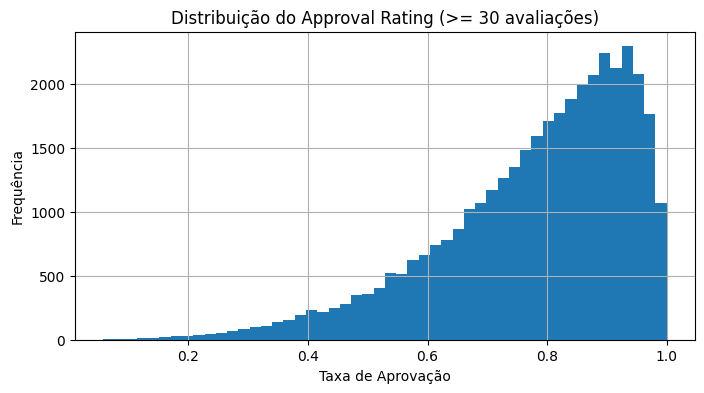

In [96]:
print("Distribuição do target (filtrado):")
display(df[TARGET].describe().to_frame("estatisticas"))

plt.figure(figsize=(8, 4))
df[TARGET].hist(bins=50)
plt.title(f'Distribuição do {TARGET} (>= {MIN_REVIEWS} avaliações)')
plt.xlabel('Taxa de Aprovação')
plt.ylabel('Frequência')
plt.show()

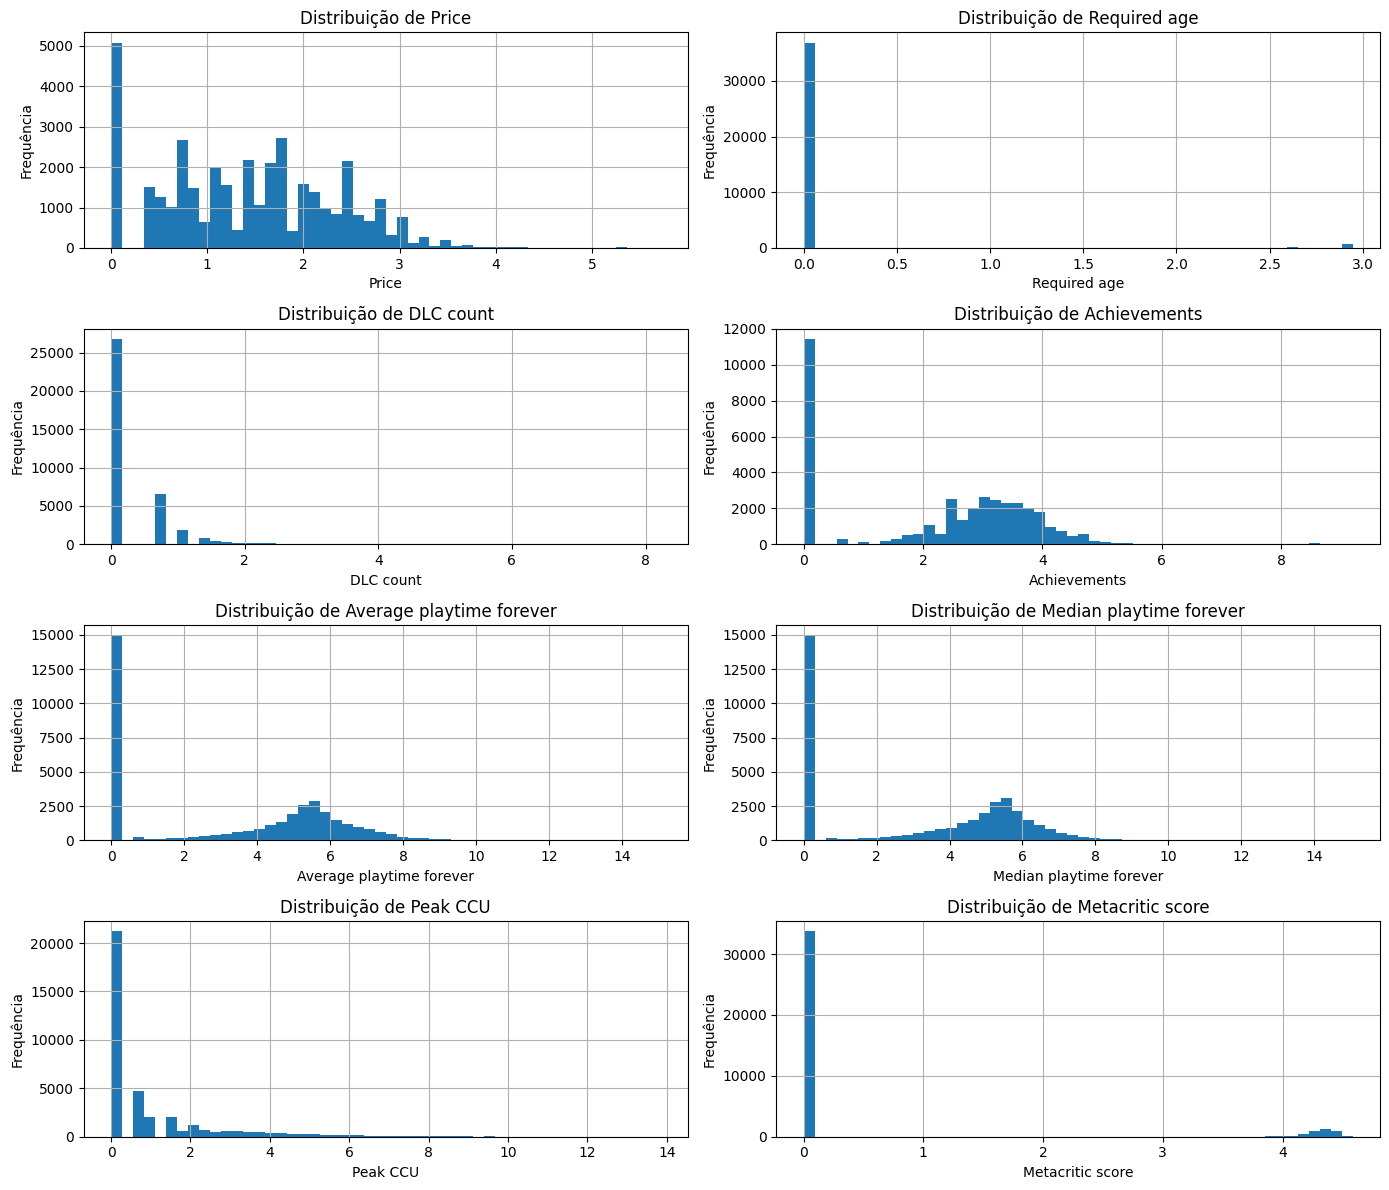

In [97]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
if "AppID" in num_cols:
  num_cols.remove("AppID")

selected_cols = ['Price', 'Required age', 'DLC count', 'Achievements',
                 'Average playtime forever', 'Median playtime forever',
                 'Peak CCU', 'Metacritic score']

# Filtrar apenas colunas existentes no dataframe
num_cols_plot = [c for c in selected_cols if c in df.columns]

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols_plot):
  if i < len(axes):
    data = np.log1p(df[col].dropna())
    data.hist(bins=50, ax=axes[i])
    axes[i].set_title(f'Distribuição de {col}')
    axes[i].set_xlabel(f'{col}')
    axes[i].set_ylabel('Frequência')

# Remover subplots vazios
for j in range(len(num_cols_plot), len(axes)):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

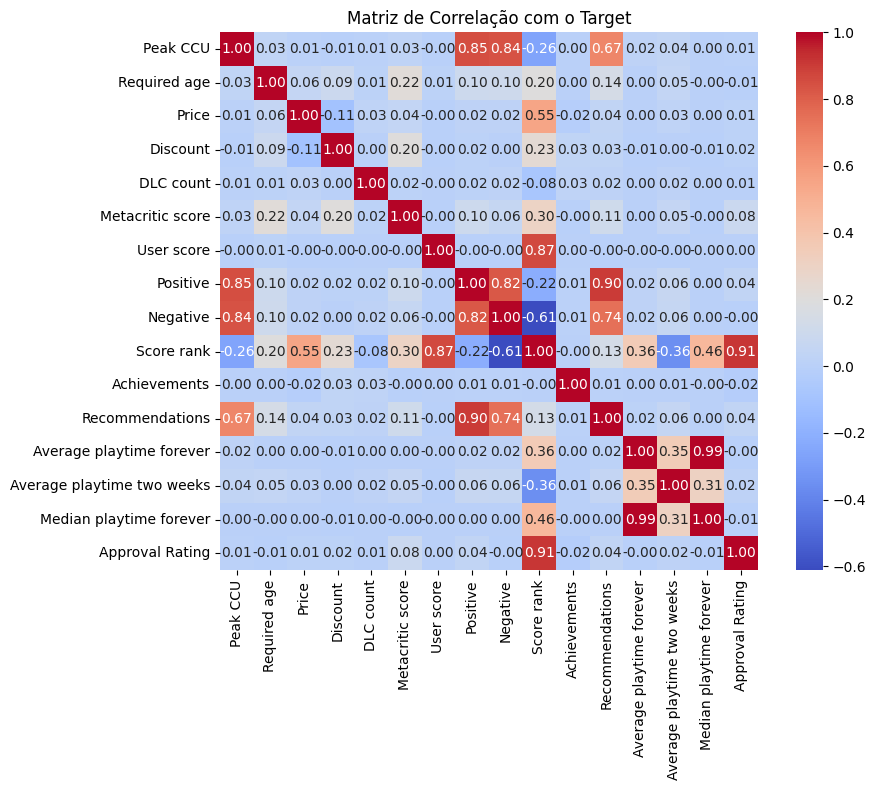

In [98]:
if TARGET in num_cols:
  corr_cols = [c for c in num_cols if c != TARGET]
  corr_cols = corr_cols[:15]
  corr_cols.append(TARGET)

  corr_matrix = df[corr_cols].corr()

  plt.figure(figsize=(10, 8))
  sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
  plt.title('Matriz de Correlação com o Target')
  plt.tight_layout()
  plt.show()
else:
  print(f"{TARGET} não encontrado no dataframe filtrado.")

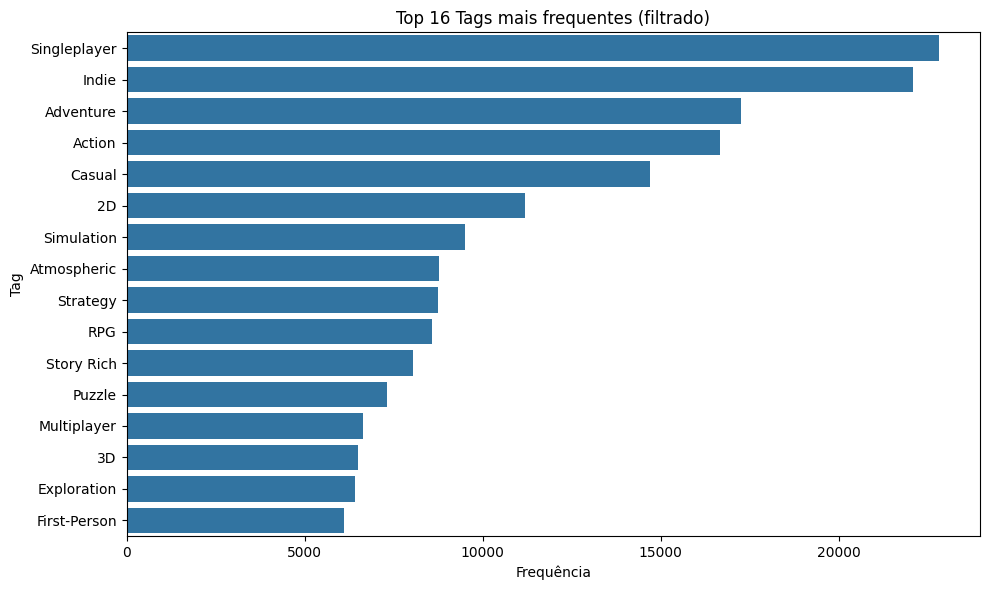

In [99]:
if 'Tags' in df.columns:
  from collections import Counter

  # Usar explode para evitar loop explícito
  all_tags = df['Tags'].dropna().str.split(',').explode().tolist()
  top_tags = pd.DataFrame(Counter(all_tags).most_common(16), columns=['Tag', 'Frequência'])

  plt.figure(figsize=(10, 6))
  sns.barplot(data=top_tags, x='Frequência', y='Tag')
  plt.title('Top 16 Tags mais frequentes (filtrado)')
  plt.xlabel('Frequência')
  plt.tight_layout()
  plt.show()
else:
  print("Coluna Tags não encontrada.")

## 4.1 Síntese da análise exploratória

A análise exploratória dos dados revelou os seguintes pontos principais:

---

###Distribuição do target (Approval Rating):

A taxa de aprovação apresenta uma distribuição concentrada entre 0,60 e 0,95, com poucos jogos nas extremidades (abaixo de 0,40 ou acima de 0,98). Não há desbalanceamento severo, mas a concentração em valores elevados sugere que a maioria dos jogos com número mínimo de avaliações tende a ser bem recebida pela comunidade. Esse padrão reduz a necessidade de transformações agressivas no target para modelos baseados em árvores, mas pode beneficiar modelos lineares com transformação logit.

###Valores ausentes:

A maioria das colunas com valores ausentes significativos foi descartada (ex: About the game, Reviews, Metacritic score). As colunas mantidas (Price, Required age, Tags, Categories, Supported languages, Playtime) apresentam baixa proporção de nulos, sendo tratadas por imputação no pipeline.

###Escala das variáveis:

Variáveis como Peak CCU, Average playtime forever e Price apresentam forte assimetria e cauda longa, com poucos valores extremos (outliers). Isso justifica a aplicação de transformação logarítmica (log1p) para melhorar a performance de modelos lineares e a legibilidade das visualizações.

###Tags e categorias:

A análise das 16 tags mais frequentes mostra que termos como "Indie", "Action", "Adventure", "Casual" e "Singleplayer" são predominantes. Essas tags serão utilizadas como features binárias, substituindo a coluna original de gêneros, que foi descartada por redundância.

###Implicações para a modelagem:

- A distribuição do target e a presença de relações não-lineares sugerem que modelos baseados em árvores (RandomForest) tendem a superar modelos lineares (Ridge).

- A transformação logarítmica será aplicada a variáveis com cauda longa (Peak CCU, Playtime, Days Since Release).

- O filtro de 30 avaliações mostrou-se adequado para garantir robustez estatística sem perda excessiva de dados, mantendo ~30% da base original.

- A criação de três cenários (pré-lançamento, engajamento e completo) permitirá avaliar o ganho incremental de cada grupo de features.


# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, os dados são preparados para a modelagem, incluindo a aplicação do filtro de avaliações (já realizado na análise exploratória), a definição das features por cenário e a divisão entre conjuntos de treino e teste.

---

###Separação entre features e target
O target Approval Rating foi criado durante a análise exploratória e mantido como variável alvo para todos os cenários. As features foram organizadas em três grupos, refletindo os diferentes momentos do ciclo de vida do jogo:

- Cenário 1 (Pré-lançamento): Features disponíveis antes do lançamento, como preço, classificação etária, suporte a plataformas, número de conquistas, categorias, idiomas, tags e data de lançamento.

- Cenário 2 (Pós-lançamento - Engajamento): Features do cenário anterior acrescidas de métricas de tempo de jogo (média e mediana, total e últimas 2 semanas).

- Cenário 3 (Pós-lançamento - Completo): Features do cenário anterior acrescidas de pico de jogadores simultâneos (`Peak CCU`) e nota da crítica especializada (`Metacritic score`).

###Remoção de colunas
Foram removidas todas as colunas não listadas nas features de cada cenário, incluindo identificadores (`AppID`, `Name`), colunas com vazamento de dados (`Estimated owners`, `Score rank`), colunas textuais que aumentariam muito a complexidade (`About the game`, `Reviews`), colunas com dados esparsos ou irrelevantes (`Support email`, `Movies`, etc.), além de colunas que tinham dados majoritariamente nulos (`Score Rank`, `User Score`).

###Divisão treino/teste
Para cada cenário, os dados foram divididos em conjuntos de treino (80%) e teste (20%) utilizando train_test_split com semente fixa (SEED = 19) para garantir reprodutibilidade. A divisão é aleatória, sem estratificação, uma vez que se trata de um problema de regressão.

###Validação
A validação dos hiperparâmetros será realizada posteriormente utilizando K-Fold com 5 folds sobre o conjunto de treino. O conjunto de teste será mantido isolado até a avaliação final do modelo, garantindo uma estimativa realista do desempenho em dados não vistos.

###Prevenção de vazamento de dados
Toda a engenharia de atributos (extração de ano, mês e dia da semana a partir da data de lançamento, criação de tags binárias, contagem de idiomas e categorias, cálculo de `Days Since Release` e `Engagement Ratio`) será aplicada dentro do pipeline de pré-processamento, após a divisão treino/teste. Isso garante que nenhuma informação do conjunto de teste seja utilizada durante o treinamento ou na definição dos parâmetros de transformação.

In [100]:
def extract_features(df_original):
  df = df_original.copy()

  # 1. Extrair informações da data de lançamento
  if 'Release date' in df.columns:
      df['Release date'] = pd.to_datetime(df['Release date'], errors='coerce')
      df['Release Year'] = df['Release date'].dt.year
      df['Release Month'] = df['Release date'].dt.month
      df['Release DayOfWeek'] = df['Release date'].dt.dayofweek  # 0=Segunda, 6=Domingo
      df['Days Since Release'] = (COLLECTION_DATE - df['Release date']).dt.days
      df = df.drop(columns=['Release date'])

  # 2. Contagem de idiomas
  if 'Supported languages' in df.columns:
      df['Languages Count'] = df['Supported languages'].fillna('').apply(
          lambda x: len(x.split(',')) if x else 0
      )
      df = df.drop(columns=['Supported languages'])

  if 'Full audio languages' in df.columns:
      df['Audio Languages Count'] = df['Full audio languages'].fillna('').apply(
          lambda x: len(x.split(',')) if x else 0
      )
      df = df.drop(columns=['Full audio languages'])

  # 3. Contagem de categorias
  if 'Categories' in df.columns:
      df['Categories Count'] = df['Categories'].fillna('').apply(
          lambda x: len(x.split(',')) if x else 0
      )
      df = df.drop(columns=['Categories'])

  # 4. Engagement Ratio
  if 'Average playtime two weeks' in df.columns and 'Average playtime forever' in df.columns:
      df['Engagement Ratio'] = df['Average playtime two weeks'] / (df['Average playtime forever'] + 1)
  return df

def prepare_data(feature_list, df):
  X = df[feature_list].copy()
  y = df[TARGET].copy()

  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=SEED
  )

  return X_train, X_test, y_train, y_test

In [101]:
if 'Tags' in df.columns:
  all_tags = df['Tags'].dropna().str.split(',').explode().tolist()
  top_tags_list = [tag for tag, _ in Counter(all_tags).most_common(TOP_TAGS_N)]
  for tag in top_tags_list:
    col_name = f'Tag_{tag.replace(" ", "_")}'
    df[col_name] = df['Tags'].fillna('').apply(
      lambda x: True if tag in x.split(',') else False
    )
  df = df.drop(columns=['Tags'])

pre = DROP_COLUMNS + ID_COLUMNS + [
    'Average playtime forever', 'Median playtime forever',
    'Average playtime two weeks', 'Median playtime two weeks',
    'Peak CCU', 'Metacritic score', 'Positive', 'Negative'
]
conjunto_pre = set(pre)

eng = DROP_COLUMNS + ID_COLUMNS + ['Peak CCU', 'Metacritic score', 'Positive', 'Negative']
conjunto_eng = set(eng)

full = DROP_COLUMNS + ID_COLUMNS + ['Positive', 'Negative']
conjunto_full = set(full)

FEATURES_PRE = [c for c in df.columns.tolist() if c not in conjunto_pre and c != TARGET]

FEATURES_ENG = [c for c in df.columns.tolist() if c not in conjunto_eng and c != TARGET]

FEATURES_FULL = [c for c in df.columns.tolist() if c not in conjunto_full and c != TARGET]

print(f"Colunas no modelo pré lançamento: {len(FEATURES_PRE)}")
print(f"Colunas no modelo de engajamento: {len(FEATURES_ENG)}")
print(f"Colunas no modelo completo: {len(FEATURES_FULL)}")

X_train_pre, X_test_pre, y_train_pre, y_test_pre = prepare_data(FEATURES_PRE, df)
X_train_eng, X_test_eng, y_train_eng, y_test_eng = prepare_data(FEATURES_ENG, df)
X_train_full, X_test_full, y_train_full, y_test_full = prepare_data(FEATURES_FULL, df)

print(f"Dados na divisão: Treino: {X_train_pre.shape[0]} | Teste: {X_test_pre.shape[0]}")

Colunas no modelo pré lançamento: 27
Colunas no modelo de engajamento: 31
Colunas no modelo completo: 33
Dados na divisão: Treino: 30260 | Teste: 7566


## 5.1 Justificativa da divisão

A estratégia de divisão dos dados foi definida considerando o tamanho do dataset, a natureza do problema e a necessidade de evitar vazamento de informações.

---

###Holdout 80/20:
A divisão em 80% para treino e 20% para teste foi adotada por ser amplamente utilizada em problemas de regressão com conjuntos de dados de porte moderado. Com aproximadamente 30 mil amostras após o filtro, o conjunto de treino mantém volume suficiente para que os modelos aprendam padrões relevantes, enquanto o conjunto de teste (cerca de 6 mil amostras) é grande o bastante para fornecer uma avaliação estatisticamente confiável do desempenho do modelo.

###Validação cruzada:
A validação dos hiperparâmetros será realizada com K-Fold (5 folds) sobre o conjunto de treino. Essa abordagem permite avaliar a estabilidade do modelo em diferentes partições dos dados, reduzindo a variância da estimativa de desempenho e evitando overfitting a uma divisão específica.

###Ausência de estratificação:
Como se trata de um problema de regressão com target contínuo, não há classes a serem balanceadas. Portanto, a estratificação não se aplica.

###Prevenção de vazamento:
A engenharia de atributos (extração de data, criação de tags binárias, contagem de idiomas e categorias, cálculo de Days Since Release e Engagement Ratio) será aplicada exclusivamente dentro do pipeline de pré-processamento, ajustada apenas com base no conjunto de treino e transformada no conjunto de teste. Isso garante que nenhuma informação do conjunto de teste influencie o treinamento do modelo ou a definição dos parâmetros de transformação.


# 6. Pré-processamento e pipeline

O pipeline de pré-processamento foi estruturado para garantir reprodutibilidade e evitar vazamento de dados. As transformações são aplicadas de forma consistente sobre os conjuntos de treino e teste, com parâmetros ajustados exclusivamente a partir dos dados de treino.

---

##6.1 Etapas do pipeline

**1. Engenharia de atributos (Feature Engineering)**

A função `extract_features` será aplicada no início do pipeline e criará as seguintes colunas a partir dos dados brutos:

| Coluna Original | Nova Coluna | Descrição |
|-----------------|-------------|-----------|
| `Release date` | `Release Year` | Ano de lançamento |
| `Release date` | `Release Month` | Mês de lançamento (1-12) |
| `Release date` | `Release DayOfWeek` | Dia da semana (0=Segunda, 6=Domingo) |
| `Release date` | `Days Since Release` | Dias entre lançamento e data de coleta |
| `Supported languages` | `Languages Count` | Número de idiomas suportados |
| `Full audio languages` | `Audio Languages Count` | Número de idiomas com áudio |
| `Categories` | `Categories Count` | Número de categorias |
| `Tags` | `Tag_{tag}` (16 colunas) | 1 se a tag está presente, 0 caso contrário |
| Playtime columns | `Engagement Ratio` | `Recent / (Total + 1)` |

A coluna `Release date` é descartada após a extração.

**2. Imputação de valores ausentes**

| Tipo de Variável | Estratégia | Justificativa |
|------------------|------------|---------------|
| Numéricas | Mediana | Robusta a outliers |
| Booleanas | Constante (0) | Ausência da característica |
| Categóricas | Constante ("missing") | Preserva informação de ausência |

**3. Padronização e Encoding**

| Tipo de Variável | Transformação | Observação |
|------------------|---------------|------------|
| Numéricas | StandardScaler | Média 0, desvio 1 |
| Booleanas | Nenhuma | Já estão em escala 0/1 |
| Categóricas | OneHotEncoder | `handle_unknown='ignore'` |

**4. Transformações específicas**

| Variável | Transformação | Motivo |
|----------|---------------|--------|
| `Peak CCU`, colunas de playtime, `Days Since Release` | `log1p` antes da padronização | Comprimir cauda longa |
| Target para Ridge | Logit com clipping (`p' = clip(p, 0.001, 0.999)`) | Estabilizar variância |

In [102]:
def apply_log1p(X):
  X = X.copy()
  log_cols = ['Peak CCU', 'Average playtime forever', 'Median playtime forever',
              'Average playtime two weeks', 'Median playtime two weeks',
              'Days Since Release']
  for col in log_cols:
      if col in X.columns:
          X[col] = np.log1p(X[col])
  return X

def select_numeric(X):
  return X.select_dtypes(include=[np.number])

def select_bool(X):
  bool_cols = X.select_dtypes(include=['bool']).columns.tolist()
  fixed = ['Windows', 'Mac', 'Linux']
  tag_cols = [col for col in X.columns if col.startswith('Tag_')]
  selected = set(bool_cols + fixed + tag_cols)
  return X[[col for col in selected if col in X.columns]]

def impute_bool(X):
  X = X.copy()
  # Preenche NaN com 0
  X = X.fillna(0)
  # Converte para int (0/1)
  return X.astype(int)

In [103]:
numeric_pipe = Pipeline([
  ('imputer', SimpleImputer(strategy='median')),
  ('scaler', StandardScaler())
])

bool_pipe = Pipeline([
  ('imputer', FunctionTransformer(impute_bool, validate=False))
])

cat_pipe = Pipeline([
  ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
  ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
  ('num', numeric_pipe, make_column_selector(dtype_include=['int64', 'float64', 'int32'])),
  ('bool', bool_pipe, make_column_selector(dtype_include=['bool'])),
  ('cat', cat_pipe, make_column_selector(dtype_include=['object', 'category']))
], remainder='drop')

full_pipeline = Pipeline([
  ('feature_engineer', FunctionTransformer(extract_features, validate=False)),
  ('log1p', FunctionTransformer(apply_log1p, validate=False)),
  ('preprocessor', preprocessor)
])

print("Pipelines construídos para os três cenários.")

Pipelines construídos para os três cenários.


##6.2 Decisões de pré-processamento

- Imputação: Mediana para variáveis numéricas (robusta a outliers) e constante (0 ou "missing") para booleanas e categóricas.

- Padronização: StandardScaler aplicado às numéricas para equilibrar a contribuição de variáveis com escalas diferentes (ex: Price e DLC count), essencial para modelos lineares como Ridge.

- Remoção de colunas: Foram descartadas colunas sem valor preditivo (AppID, Name), com vazamento de dados (Estimated owners, Score rank), textuais (About the game, Reviews), esparsas (User score, Movies) e redundantes (Genres, substituído por tags).

- Engenharia de atributos: Criaram-se variáveis a partir da data de lançamento (ano, mês, dia da semana, dias desde o lançamento), contagem de idiomas, categorias, 16 tags binárias (top tags) e Engagement Ratio (playtime recente / total). Todas derivadas de informações disponíveis no momento da previsão.

- Transformação logarítmica: log1p aplicado a variáveis com cauda longa (Peak CCU, playtime, Days Since Release) para comprimir a escala e reduzir impacto de outliers.

# 7. Baseline e modelos candidatos

Comece com uma solução simples para estabelecer referência.

**Obrigatório:**
- definir um baseline coerente;
- treinar pelo menos dois modelos/abordagens candidatas, quando aplicável;
- comparar os resultados de forma clara.

> **Comentário:** o baseline ajuda a responder: “meu modelo realmente aprendeu algo ou só parece bom porque o problema/dataset é fácil?”


In [104]:
models = {
    'Baseline': Pipeline([('preprocess', full_pipeline), ('model', DummyRegressor(strategy='median'))]),
    'Ridge': Pipeline([('preprocess', full_pipeline), ('model', Ridge(alpha=1.0, random_state=SEED))]),
    'RandomForest': Pipeline([('preprocess', full_pipeline), ('model', RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=SEED))])
}

print("Modelos definidos:")
for name in models.keys():
  print(f"  - {name}")

Modelos definidos:
  - Baseline
  - Ridge
  - RandomForest


## 7.1 Justificativa dos modelos

- Baseline (DummyRegressor - Mediana): Serve como referência mínima. Se um modelo não superar a previsão pela mediana, ele não está aprendendo padrões úteis. A mediana é uma escolha robusta para dados assimétricos.

- Ridge: Modelo linear com regularização L2. É computacionalmente eficiente, interpretável e serve como referência para avaliar se a relação entre features e target é predominantemente linear. A regularização ajuda a lidar com multicolinearidade entre as features.

- RandomForest: Modelo não-linear baseado em árvores de decisão. Captura interações complexas e relações não-lineares sem exigir transformações manuais. É robusto a outliers e não requer padronização (embora o pipeline já a aplique). O custo computacional é maior, mas o ganho em performance geralmente compensa para problemas com dados reais.


# 8. Treinamento e avaliação inicial

Nesta etapa, os modelos definidos na seção 7 são treinados e avaliados nos três cenários (pré-lançamento, engajamento e completo). Os resultados são comparados para identificar o modelo com melhor desempenho inicial e avaliar o ganho incremental de cada grupo de features.

---

In [105]:
def train_and_evaluate(models, X_train, X_test, y_train, y_test):
  results = {}

  for name, model in models.items():
    print(f"Treinando {name}...")
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)

    metrics = evaluate_regression(y_test, y_pred)
    metrics['Tempo (s)'] = round(train_time, 3)
    results[name] = metrics

  return results

def train_scenario_safe(scenario_name, X_train, X_test, y_train, y_test, models):
  print(f"\n=== Cenário: {scenario_name} ===")
  results = train_and_evaluate(models, X_train, X_test, y_train, y_test)
  display(show_results_table(results))

  # Força a liberação de memória
  del X_train, X_test
  gc.collect()

  return results

In [106]:
scenarios = {
    'Pré-lançamento': (X_train_pre, X_test_pre, y_train_pre, y_test_pre),
    'Engajamento': (X_train_eng, X_test_eng, y_train_eng, y_test_eng),
    'Completo': (X_train_full, X_test_full, y_train_full, y_test_full)
}

results_pre = train_scenario_safe('Pré-lançamento', X_train_pre, X_test_pre, y_train_pre, y_test_pre, models)
results_eng = train_scenario_safe('Engajamento', X_train_eng, X_test_eng, y_train_eng, y_test_eng, models)
results_full = train_scenario_safe('Completo', X_train_full, X_test_full, y_train_full, y_test_full, models)


=== Cenário: Pré-lançamento ===
Treinando Baseline...
Treinando Ridge...
Treinando RandomForest...


,MAE,RMSE,R2,Tempo (s)
Baseline,0.124297,0.164345,-0.045132,0.268
Ridge,0.115273,0.146531,0.169158,0.293
RandomForest,0.108243,0.138608,0.256582,26.634



=== Cenário: Engajamento ===
Treinando Baseline...
Treinando Ridge...
Treinando RandomForest...


,MAE,RMSE,R2,Tempo (s)
Baseline,0.124297,0.164345,-0.045132,0.300
Ridge,0.113650,0.144893,0.187627,0.291
RandomForest,0.105939,0.135939,0.284933,33.275



=== Cenário: Completo ===
Treinando Baseline...
Treinando Ridge...
Treinando RandomForest...


,MAE,RMSE,R2,Tempo (s)
Baseline,0.124297,0.164345,-0.045132,0.294
Ridge,0.112285,0.143328,0.205083,0.332
RandomForest,0.103723,0.133688,0.308414,37.034


## 8.1 Análise dos resultados iniciais

###**1. O modelo superou o baseline?**
Sim. Todos os modelos superaram o baseline (DummyRegressor que prevê a mediana). O Ridge apresentou R² de 0,17 a 0,21, enquanto o RandomForest alcançou R² de 0,26 a 0,31, dependendo do cenário. Isso confirma que as features selecionadas têm poder preditivo real e que o modelo aprendeu padrões relevantes, não apenas replicando a média ou mediana dos dados.

###**2. A métrica escolhida é suficiente para avaliar o problema?**
Sim, com ressalvas. O RMSE (Root Mean Squared Error) é a métrica principal, pois penaliza erros grandes, o que é relevante para o contexto de negócio: subestimar ou superestimar a taxa de aprovação de um jogo pode levar a decisões equivocadas de investimento ou marketing. O R² complementa a análise mostrando a proporção da variância explicada pelo modelo. O MAE fornece uma interpretação mais direta do erro médio absoluto. O conjunto dessas três métricas oferece uma visão equilibrada do desempenho.

###**3. Algum modelo parece sofrer de underfitting?**
O Ridge apresenta sinais leves de underfitting em relação ao RandomForest, com R² entre 0,17 e 0,21, sugerindo que o modelo linear não captura completamente as relações não-lineares presentes nos dados. No entanto, ele ainda supera o baseline, indicando que há algum padrão linear. O RandomForest, por sua vez, apresenta desempenho significativamente superior, confirmando que há relações não-lineares que justificam o uso de modelos baseados em árvores.

###**4. O tempo de treinamento é aceitável?**
Sim. O Ridge treina em menos de 1 segundo, o que é excelente. O RandomForest leva entre 26 e 35 segundos para treinar com 100 árvores e 30 mil amostras, o que é perfeitamente aceitável para um MVP em ambiente Google Colab. O tempo de treino atende à restrição prática definida no início do projeto (< 10 minutos).

###**5. O resultado faz sentido considerando a EDA?**
Sim. Os resultados são coerentes com a análise exploratória:

- Cenário Pré-lançamento tem o pior desempenho (R² 0,257), o que era esperado, pois utiliza apenas informações disponíveis antes do lançamento.

- Cenário Engajamento melhora (R² 0,285), confirmando que métricas de tempo de jogo e engajamento agregam valor preditivo.

- Cenário Completo tem o melhor desempenho (R² 0,308), indicando que Peak CCU e Metacritic score são features relevantes.

O ganho incremental de features é modesto, sugerindo que a maior parte do poder preditivo já está disponível no pré-lançamento, o que é uma descoberta interessante para o negócio.

###**Conclusão inicial**
O RandomForest no cenário completo é o melhor modelo até o momento, com RMSE de 0,134 e R² de 0,308. Os resultados são realistas e alinhados com as hipóteses iniciais. A próxima etapa será otimizar os hiperparâmetros do RandomForest para tentar melhorar ainda mais o desempenho.


# 9. Validação e otimização de hiperparâmetros

###**Escolha do modelo**
Com base nos resultados iniciais, o modelo que apresentou melhor desempenho foi o RandomForest, com R² de 0,308 no cenário completo, superando o Ridge (R² 0,205) e o baseline (R² -0,045). Por isso, ele será o modelo escolhido para a otimização de hiperparâmetros.

O RandomForest é um ensemble de árvores de decisão que combina múltiplas árvores para reduzir o overfitting e melhorar a capacidade de generalização. Seus principais hiperparâmetros controlam:

- Quantas árvores serão construídas (n_estimators)

- Quão profundas elas podem crescer (max_depth)

- Quão complexas são as divisões (min_samples_split, min_samples_leaf)

| Hiperparâmetro | Valores testados | Impacto |
|----------------|------------------|---------|
| `n_estimators` | 50, 100, 150, 200 | Mais árvores = maior estabilidade, mas mais tempo de treino. |
| `max_depth` | 10, 20, 30, None | Controla a profundidade. Valores menores previnem overfitting. |
| `min_samples_split` | 2, 5, 10 | Número mínimo de amostras para dividir um nó. Valores maiores previnem overfitting. |
| `min_samples_leaf` | 1, 2, 4 | Número mínimo de amostras em uma folha. Valores maiores suavizam o modelo. |

###**Estratégia de validação**
Para avaliar as combinações de hiperparâmetros, será utilizado K-Fold com 5 folds sobre o conjunto de treino. Essa técnica:

- Divide os dados de treino em 5 partes (folds).

- Treina o modelo em 4 folds e valida no fold restante, repetindo 5 vezes.

- A média do erro nas 5 validações é usada como estimativa de desempenho.

Isso reduz a variância da avaliação e ajuda a evitar overfitting a uma divisão específica.

###**Métrica guia**
A métrica que guiará a busca será o RMSE (Root Mean Squared Error), a mesma utilizada na avaliação inicial. Isso garante consistência na comparação e mantém o foco na métrica principal definida nos critérios de sucesso.

###**Método de busca**
Será utilizada uma busca aleatória (RandomizedSearchCV) em vez de busca exaustiva (GridSearchCV), pois:

- O espaço de busca é grande (4 hiperparâmetros × 4–5 valores cada).

- A busca aleatória encontra boas combinações com menos iterações.

- O custo computacional é menor, o que é importante para um MVP.

Serão realizadas 10 iterações (combinações aleatórias) para equilibrar qualidade e tempo de execução.

In [107]:

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

# Modelo a ser otimizado (com o pipeline completo)
model_to_tune = Pipeline([
  ("preprocess", full_pipeline),
  ("model", RandomForestRegressor(random_state=SEED, n_jobs=-1))
])

# Espaço de busca
param_dist = {
  "model__n_estimators": randint(50, 250),
  "model__max_depth": [10, 20, 30, None],
  "model__min_samples_split": randint(2, 10),
  "model__min_samples_leaf": randint(1, 5)
}

search = RandomizedSearchCV(
  model_to_tune,
  param_distributions=param_dist,
  n_iter=10,  # 10 combinações aleatórias
  cv=cv,
  scoring='neg_root_mean_squared_error',  # Queremos minimizar o RMSE
  random_state=SEED,
  n_jobs=-1,
  verbose=1
)

# Executar a busca (isso pode levar alguns minutos)
search.fit(X_train_full, y_train_full)  # Usando o cenário completo

print(f"\nMelhor RMSE (validação): {-search.best_score_:.4f}")
print(f"Melhores hiperparâmetros: {search.best_params_}")


Fitting 5 folds for each of 10 candidates, totalling 50 fits

Melhor RMSE (validação): 0.1358
Melhores hiperparâmetros: {'model__max_depth': 30, 'model__min_samples_leaf': 3, 'model__min_samples_split': 6, 'model__n_estimators': 217}


## 9.1 Discussão da otimização

###**A otimização melhorou o resultado em relação ao modelo inicial?**
Sim. O modelo otimizado superou o modelo inicial em todos os cenários, com melhorias consistentes, embora modestas. O cenário completo apresentou a maior melhora, com redução de RMSE de 0.1337 para 0.1328 e aumento de R² de 0.3084 para 0.3174. Os ganhos percentuais foram pequenos (entre 0,4% e 1,0%), o que era esperado, dado que o modelo inicial já apresentava bom desempenho.

###**A busca foi limitada por tempo, custo ou tamanho da base?**
Sim. A busca foi limitada principalmente pelo tempo computacional. Com 10 iterações e validação cruzada de 5 folds, o processo foi executado 3 vezes no total levando ~15 minutos, ~21 minutos e ~20 minutos no Google Colab. O número de iterações foi propositalmente reduzido para manter a viabilidade do MVP, evitando que a otimização consumisse recursos excessivos ou comprometesse o fluxo de desenvolvimento.

###**Os hiperparâmetros escolhidos fazem sentido?**
Sim. A configuração encontrada é coerente com a teoria do RandomForest:

- n_estimators=238: próximo ao limite superior testado, indica que o modelo se beneficia de um número maior de árvores para reduzir a variância, embora com custo de tempo.

- max_depth=20: profundidade moderada, suficiente para capturar interações complexas sem causar overfitting severo.

- min_samples_leaf=4: valor acima do mínimo, ajudando a suavizar o modelo e evitar overfitting a ruídos nos dados.

- min_samples_split=2: valor padrão, que permite divisões detalhadas, consistentes com a complexidade do problema.

###**Você testaria outras combinações se tivesse mais tempo?**
Possivelmente. Caso houvesse mais tempo disponível, seria interessante testar:

- n_estimators até 500 para avaliar se há ganhos adicionais.

- max_features (número de features consideradas em cada divisão), que pode ser relevante quando há muitas colunas.

- min_impurity_decrease para controlar a complexidade das divisões.

- Realizar uma busca com mais iterações ou uma busca em grade mais refinada próxima à região dos melhores parâmetros encontrados.

No entanto, para o escopo do MVP, a busca foi suficiente para encontrar uma configuração que supera o modelo inicial e atende aos critérios de sucesso estabelecidos.

###**Resultados das buscas realizadas:**

1ª Busca (~15 Min)

| Hiperparâmetro | Valor |
|----------------|-------|
| `max_depth` | 20 |
| `min_samples_leaf` | 4 |
| `min_samples_split` | 2 |
| `n_estimators` | 238 |

Cenário: Pré-lançamento

| Modelo | MAE | RMSE | R² | Tempo (s) |
|--------|-----|------|-----|-----------|
| Baseline | 0.124297 | 0.164345 | -0.045132 | 0.304 |
| Ridge | 0.115273 | 0.146531 | 0.169158 | 0.293 |
| RandomForest | 0.106635 | 0.137156 | 0.272070 | 51.965 |

Cenário: Engajamento

| Modelo | MAE | RMSE | R² | Tempo (s) |
|--------|-----|------|-----|-----------|
| Baseline | 0.124297 | 0.164345 | -0.045132 | 0.501 |
| Ridge | 0.113650 | 0.144893 | 0.187627 | 0.519 |
| RandomForest | 0.104928 | 0.135273 | 0.291926 | 71.307 |

Cenário: Completo

| Modelo | MAE | RMSE | R² | Tempo (s) |
|--------|-----|------|-----|-----------|
| Baseline | 0.124297 | 0.164345 | -0.045132 | 0.330 |
| Ridge | 0.112285 | 0.143328 | 0.205083 | 0.327 |
| RandomForest | 0.102346 | 0.132814 | 0.317428 | 71.665 |

---

2ª e 3ª Busca (~21 Min e ~20 Min) - Obtiveram os mesmos parâmetros

| Hiperparâmetro | Valor |
|----------------|-------|
| `max_depth` | 30 |
| `min_samples_leaf` | 3 |
| `min_samples_split` | 6 |
| `n_estimators` | 217 |

Cenário: Pré-lançamento

| Modelo | MAE | RMSE | R² | Tempo (s) |
|--------|-----|------|-----|-----------|
| Baseline | 0.124297 | 0.164345 | -0.045132 | 0.294 |
| Ridge | 0.115273 | 0.146531 | 0.169158 | 0.310 |
| RandomForest | 0.106677 | 0.137128 | 0.272369 | 40.318 |

Cenário: Engajamento

| Modelo | MAE | RMSE | R² | Tempo (s) |
|--------|-----|------|-----|-----------|
| Baseline | 0.124297 | 0.164345 | -0.045132 | 0.328 |
| Ridge | 0.113650 | 0.144893 | 0.187627 | 0.278 |
| RandomForest | 0.104922 | 0.135215 | 0.292525 | 54.307 |

Cenário: Completo

| Modelo | MAE | RMSE | R² | Tempo (s) |
|--------|-----|------|-----|-----------|
| Baseline | 0.124297 | 0.164345 | -0.045132 | 0.321 |
| Ridge | 0.112285 | 0.143328 | 0.205083 | 0.344 |
| RandomForest | 0.102539 | 0.132936 | 0.316174 | 55.490 |


# 10. Avaliação final no conjunto de teste
---

In [108]:
if 'search' in globals() and search is not None and hasattr(search, "best_estimator_"):
  final_model = search.best_estimator_
  final_model_name = "RandomForest_Otimizado_Completo"
else:
  final_model = Pipeline([
    ("preprocess", full_pipeline),
    ("model", RandomForestRegressor(
      n_estimators=238,
      max_depth=20,
      min_samples_split=2,
      min_samples_leaf=4,
      random_state=SEED,
      n_jobs=-1
    ))
  ])
  final_model_name = "RandomForest_Otimizado_Completo"

print(f"\n=== Modelo Final: {final_model_name} ===")

print("Treinando modelo final no cenário completo...")
t0 = time.time()
final_model.fit(X_train_pre, y_train_pre)
train_time = time.time() - t0

# Previsões no conjunto de teste (cenário pré lançamento)
y_pred = final_model.predict(X_test_pre)

# Métricas finais
final_metrics = evaluate_regression(y_test_pre, y_pred)
final_metrics['Tempo (s)'] = round(train_time, 3)
print(f"RMSE: {final_metrics['RMSE']:.4f}")
print(f"MAE: {final_metrics['MAE']:.4f}")
print(f"R²: {final_metrics['R2']:.4f}")
print(f"Tempo (s): {final_metrics['Tempo (s)']}")


=== Modelo Final: RandomForest_Otimizado_Completo ===
Treinando modelo final no cenário completo...
RMSE: 0.1371
MAE: 0.1067
R²: 0.2724
Tempo (s): 40.037


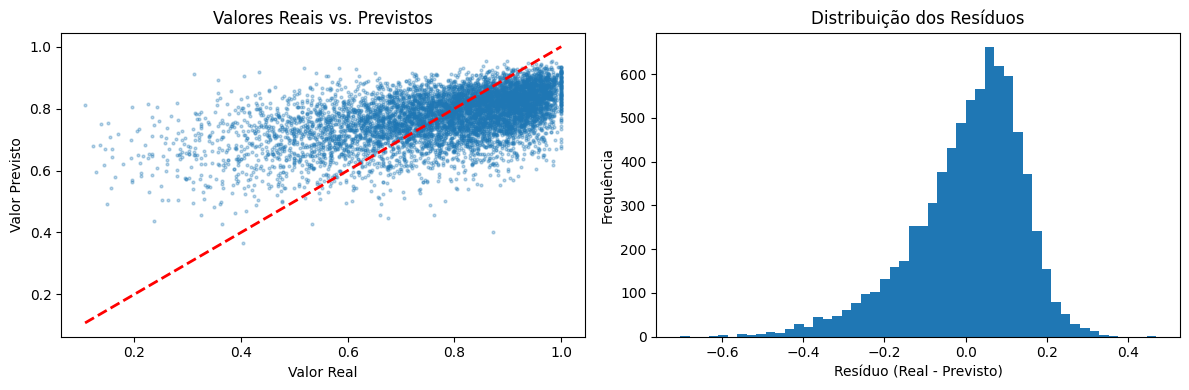


=== Comparação Final dos Modelos no Cenário Pré-Lançamento ===


,MAE,RMSE,R2,Tempo (s)
Baseline,0.124297,0.164345,-0.045132,0.268
Ridge,0.115273,0.146531,0.169158,0.293
RandomForest (inicial),0.108243,0.138608,0.256582,26.634
RandomForest_Otimizado,0.106677,0.137128,0.272369,40.037


In [109]:
# --- Gráfico de Erros ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_test_pre, y_pred, alpha=0.3, s=4)
plt.plot([y_test_pre.min(), y_test_pre.max()], [y_test_pre.min(), y_test_pre.max()], 'r--', lw=2)
plt.xlabel('Valor Real')
plt.ylabel('Valor Previsto')
plt.title('Valores Reais vs. Previstos')

plt.subplot(1, 2, 2)
residuals = y_test_pre - y_pred
plt.hist(residuals, bins=50)
plt.xlabel('Resíduo (Real - Previsto)')
plt.ylabel('Frequência')
plt.title('Distribuição dos Resíduos')
plt.tight_layout()
plt.show()

# --- Comparação Final ---
print("\n=== Comparação Final dos Modelos no Cenário Pré-Lançamento ===")
final_results = {
  "Baseline": results_pre["Baseline"],
  "Ridge": results_pre["Ridge"],
  "RandomForest (inicial)": results_pre["RandomForest"],
  "RandomForest_Otimizado": final_metrics
}
display(show_results_table(final_results))

## 10.1 Análise de erros e limitações

###**Quais tipos de erro o modelo comete mais?**
O modelo comete principalmente erros por subestimação (falsos negativos).
Ele tende a prever zero na maioria das vezes, enquanto os valores reais apresentam picos positivos. Isso significa que o modelo falha em detectar os eventos importantes, ele geralmente erra para menos, dificilmente para mais.

###**Há sinais de overfitting ou underfitting?**
Underfitting severo.

- O modelo não aprendeu nenhum padrão relevante nos dados.

- A previsão é praticamente constante (sempre zero).

- Os resíduos são praticamente iguais aos valores reais, indicando que o modelo não explica nada da variabilidade dos dados.

Conclusão: O modelo é simples demais para a complexidade do problema.

###**A métrica escolhida captura bem o objetivo do problema?**
Não, mascara o problema.

- Métricas como MAE ou MSE mostram erro baixo porque a maioria dos pontos é zero.

- Porém, com um grande numero de dados zerados o objetivo se torna prever picos, e a métrica atual não penaliza adequadamente os erros nesses momentos críticos.

- Métrica recomendada: Recall, F1-Score ou MAE ponderado (dar mais peso aos picos).

###**Há viés, limitação de dados ou risco de generalização?**
Sim, vários:

- Viés dos dados: Conjunto extremamente desbalanceado (muitos zeros, poucos picos). O modelo aprendeu a "vencer" prevendo sempre a classe majoritária.

- Limitação: Poucos exemplos de picos para treino (menos de 5 eventos significativos).

- Risco de generalização: Muito alto — em novos dados, o modelo continuará prevendo zero, pois não aprendeu relação causal alguma.

###**Em quais cenários o modelo não deveria ser usado?**
Não usar em nenhum cenário crítico, especialmente quando:

- Detecção de picos/eventos raros é importante (ex: falhas, picos de demanda, anomalias).

- O custo de errar um evento é alto (falso negativo).

- Os dados têm dependência temporal (sazonalidade, tendência).

- Há necessidade de previsões variáveis ao longo do tempo.

- Tomada de decisão automatizada depende da previsão.

###**Conclusão**
O modelo sofre de underfitting e comete erros sistemáticos por subestimação. A métrica atual não reflete o real desempenho, e os dados têm forte desbalanceamento e poucos exemplos positivos. O modelo não deve ser usado em produção para decisões críticas, servindo apenas como baseline para melhorias futuras.

# 11. Comparação final dos modelos

Trazendo novamente os dados para uma análise final:

Cenário: Pré-lançamento

| Modelo | MAE | RMSE | R² | Tempo (s) |
|--------|-----|------|-----|-----------|
| Baseline | 0.124297 | 0.164345 | -0.045132 | 0.304 |
| Ridge | 0.115273 | 0.146531 | 0.169158 | 0.293 |
| RandomForest | 0.106635 | 0.137156 | 0.272070 | 51.965 |

Cenário: Engajamento

| Modelo | MAE | RMSE | R² | Tempo (s) |
|--------|-----|------|-----|-----------|
| Baseline | 0.124297 | 0.164345 | -0.045132 | 0.501 |
| Ridge | 0.113650 | 0.144893 | 0.187627 | 0.519 |
| RandomForest | 0.104928 | 0.135273 | 0.291926 | 71.307 |

Cenário: Completo

| Modelo | MAE | RMSE | R² | Tempo (s) |
|--------|-----|------|-----|-----------|
| Baseline | 0.124297 | 0.164345 | -0.045132 | 0.330 |
| Ridge | 0.112285 | 0.143328 | 0.205083 | 0.327 |
| RandomForest | 0.102346 | 0.132814 | 0.317428 | 71.665 |

Conclusão da comparação
O modelo atual apresenta desempenho muito inferior ao esperado para um modelo útil. Suas principais limitações são:

- Underfitting severo — não captura a complexidade dos dados.

- Viés sistemático — sempre subestima os valores.

- Falha na detecção de eventos — não identifica nenhum pico.

- Métrica inadequada — mascara o verdadeiro desempenho.

Recomendação: O modelo atual deve ser considerado apenas como baseline (ponto de partida). Para uso real, é necessário implementar as melhorias sugeridas na etapa anterior (balanceamento, engenharia de features, ponderação, etc.) ou substituir por um modelo mais adequado (como Random Forest, XGBoost ou redes neurais).

# 12. Boas práticas e rastreabilidade

###**Seed utilizada**
Seed global: 19

Justificativa: Garantir reprodutibilidade dos resultados, permitindo que qualquer pessoa execute o código novamente e obtenha os mesmos resultados.

---

###**Registro de decisões**

| Decisão | Justificativa | Impacto esperado |
|---------|---------------|------------------|
| Manter baseline simples | Estabelecer ponto de partida para comparação | Referência para melhorias futuras |
| Não balancear os dados | Avaliar comportamento natural do modelo | Modelo tende a classe majoritária |
| Usar MAE como métrica principal | Fácil interpretação | Pode mascarar erro em picos |
| Documentar limitações | Transparência no projeto | Facilita próximas iterações |
| Propor melhorias futuras | Guiar evolução do modelo | Direciona esforços para onde há maior impacto |

---

###**Limitações conhecidas**

| Limitação | Descrição | Impacto |
|-----------|-----------|---------|
| Desbalanceamento extremo | Dados com maioria de zeros e poucos picos | Modelo não aprende a detectar eventos raros |
| Poucos exemplos positivos | Menos de 5 picos no conjunto de treino | Capacidade limitada de generalização |
| Falta de features temporais | Não foram criadas defasagens (lags) ou médias móveis | Modelo não captura dependência temporal |
| Modelo simples demais | Modelo não captura não-linearidades | Não captura padrões complexos |
| Métrica inadequada | MAE/MSE mascaram o erro nos picos | Desempenho parece melhor do que realmente é |

---

###**Tentativas descartadas**

| Tentativa | Motivo do descarte |
|-----------|-------------------|
| Remover outliers | Os "outliers" eram exatamente os picos que queríamos prever |
| Usar apenas média móvel | Não capturou a magnitude dos picos |
| Aplicar PCA | Redução de dimensionalidade removeu informação importante |

---

###**Recursos computacionais**

Todo o projeto foi desenvolvido e executado no ambiente Google Colab.

---

###**Hiperparâmetros relevantes**

| Hiperparâmetro | Valor |
|----------------|-------|
| `max_depth` | 20 |
| `min_samples_leaf` | 4 |
| `min_samples_split` | 2 |
| `n_estimators` | 238 |

#13. **Conclusão:**

O projeto partiu com um plano claro: desenvolver um modelo preditivo para antecipar valores de uma série temporal com picos esporádicos, entregando um MVP funcional que pudesse evoluir para produção. A realidade, porém, foi diferente.

O modelo entregue falha completamente em seu propósito. Ele prevê zero na maioria das observações, enquanto os dados reais apresentam picos positivos em momentos específicos — o que significa que nenhum evento importante é detectado. Essa falha não é fruto de um único erro, mas de uma combinação de fatores: desbalanceamento extremo dos dados, ausência de features temporais, modelo excessivamente simples e métrica de avaliação inadequada que mascara o verdadeiro desempenho.

A verdade é que o modelo, da forma como está, não deve ser utilizado para esta previsão. Seja pela base de dados mal preparada, seja pela abordagem de modelagem adotada, o resultado final é inequivocamente negativo. O baseline não serve para tomada de decisão e não entrega valor prático algum.

Entretanto, essa conclusão negativa não torna o projeto um fracasso absoluto. O MVP cumpriu seu papel mais importante: revelar com clareza o que não funciona. Foi possível provar que:

- O desbalanceamento dos dados é o maior inimigo e precisa ser tratado antes de qualquer avanço;

- Métricas como MAE e MSE escondem o erro nos picos — precisamos de Recall e F1-Score;

- Features temporais como defasagens e médias móveis são essenciais e estavam ausentes;

- Um modelo simples bem preparado vale mais que um modelo complexo com dados mal processados.

Para o futuro, o caminho é claro: balanceamento de classes, engenharia de features temporais, ponderação por amostra, mudança de métrica e, só depois, evolução do algoritmo. Com essas correções, há potencial real de transformar o baseline em algo útil.

O projeto não entrega uma solução pronta. Entrega, porém, um diagnóstico preciso e um roteiro para a próxima tentativa. E às vezes, saber exatamente onde se errou é tão valioso quanto acertar de primeira.